# 02 - スペクトル前処理
**近赤外研究会 スペクトル分析チャレンジ**

## このノートブックの目的
- SNV（Standard Normal Variate）の実装
- Savitzky-Golay 微分（1次・2次）の実装
- 各前処理の効果を可視化・比較
- 前処理済みデータを保存（次のノートブックで使用）

## 0. ライブラリのインポート

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import japanize_matplotlib
from scipy.signal import savgol_filter
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Path('figs').mkdir(exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 1. データの読み込み

In [2]:
train = pd.read_csv('../data/train_near.csv', encoding='cp932')
test  = pd.read_csv('../data/test_near.csv',  encoding='cp932')

META_COLS   = ['sample number', 'species number', '樹種', '含水率']
SPEC_COLS   = [c for c in train.columns if c not in META_COLS]
WAVENUMS    = np.array([float(c) for c in SPEC_COLS])
WAVELENGTHS = 10_000 / WAVENUMS * 1000

X_train = train[SPEC_COLS].values
X_test  = test[SPEC_COLS].values
y_train = train['含水率'].values

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')

Train : (1322, 1555)
Test  : (550, 1555)


## 2. 前処理関数の定義

### SNV（Standard Normal Variate）
各スペクトルを平均0・標準偏差1に正規化する。  
サンプル間の散乱差（粒子サイズ・光路長のばらつき）を補正するのに有効。

$$\text{SNV}(x_i) = \frac{x_i - \bar{x}}{\sigma_x}$$

### Savitzky-Golay 微分
多項式フィッティングによる平滑化微分。ノイズを抑えながらスペクトルの変化を強調する。  
1次微分はベースライン除去に、2次微分はピークの分離に有効。

In [3]:
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std


def sg_deriv(X, window_length=11, polyorder=2, deriv=1):
    return savgol_filter(X, window_length=window_length,
                         polyorder=polyorder, deriv=deriv, axis=1)


print('前処理関数を定義しました')

前処理関数を定義しました


## 3. 各前処理の適用

In [4]:
X_train_snv    = snv(X_train)
X_train_sg1    = sg_deriv(X_train, deriv=1)
X_train_sg2    = sg_deriv(X_train, deriv=2)
X_train_snv_sg1 = sg_deriv(snv(X_train), deriv=1)
X_train_snv_sg2 = sg_deriv(snv(X_train), deriv=2)

X_test_snv     = snv(X_test)
X_test_sg1     = sg_deriv(X_test, deriv=1)
X_test_sg2     = sg_deriv(X_test, deriv=2)
X_test_snv_sg1 = sg_deriv(snv(X_test), deriv=1)
X_test_snv_sg2 = sg_deriv(snv(X_test), deriv=2)

print('前処理完了')

前処理完了


## 4. 可視化：前処理の効果比較
含水率の低・中・高グループから各1サンプルを選んで比較する。

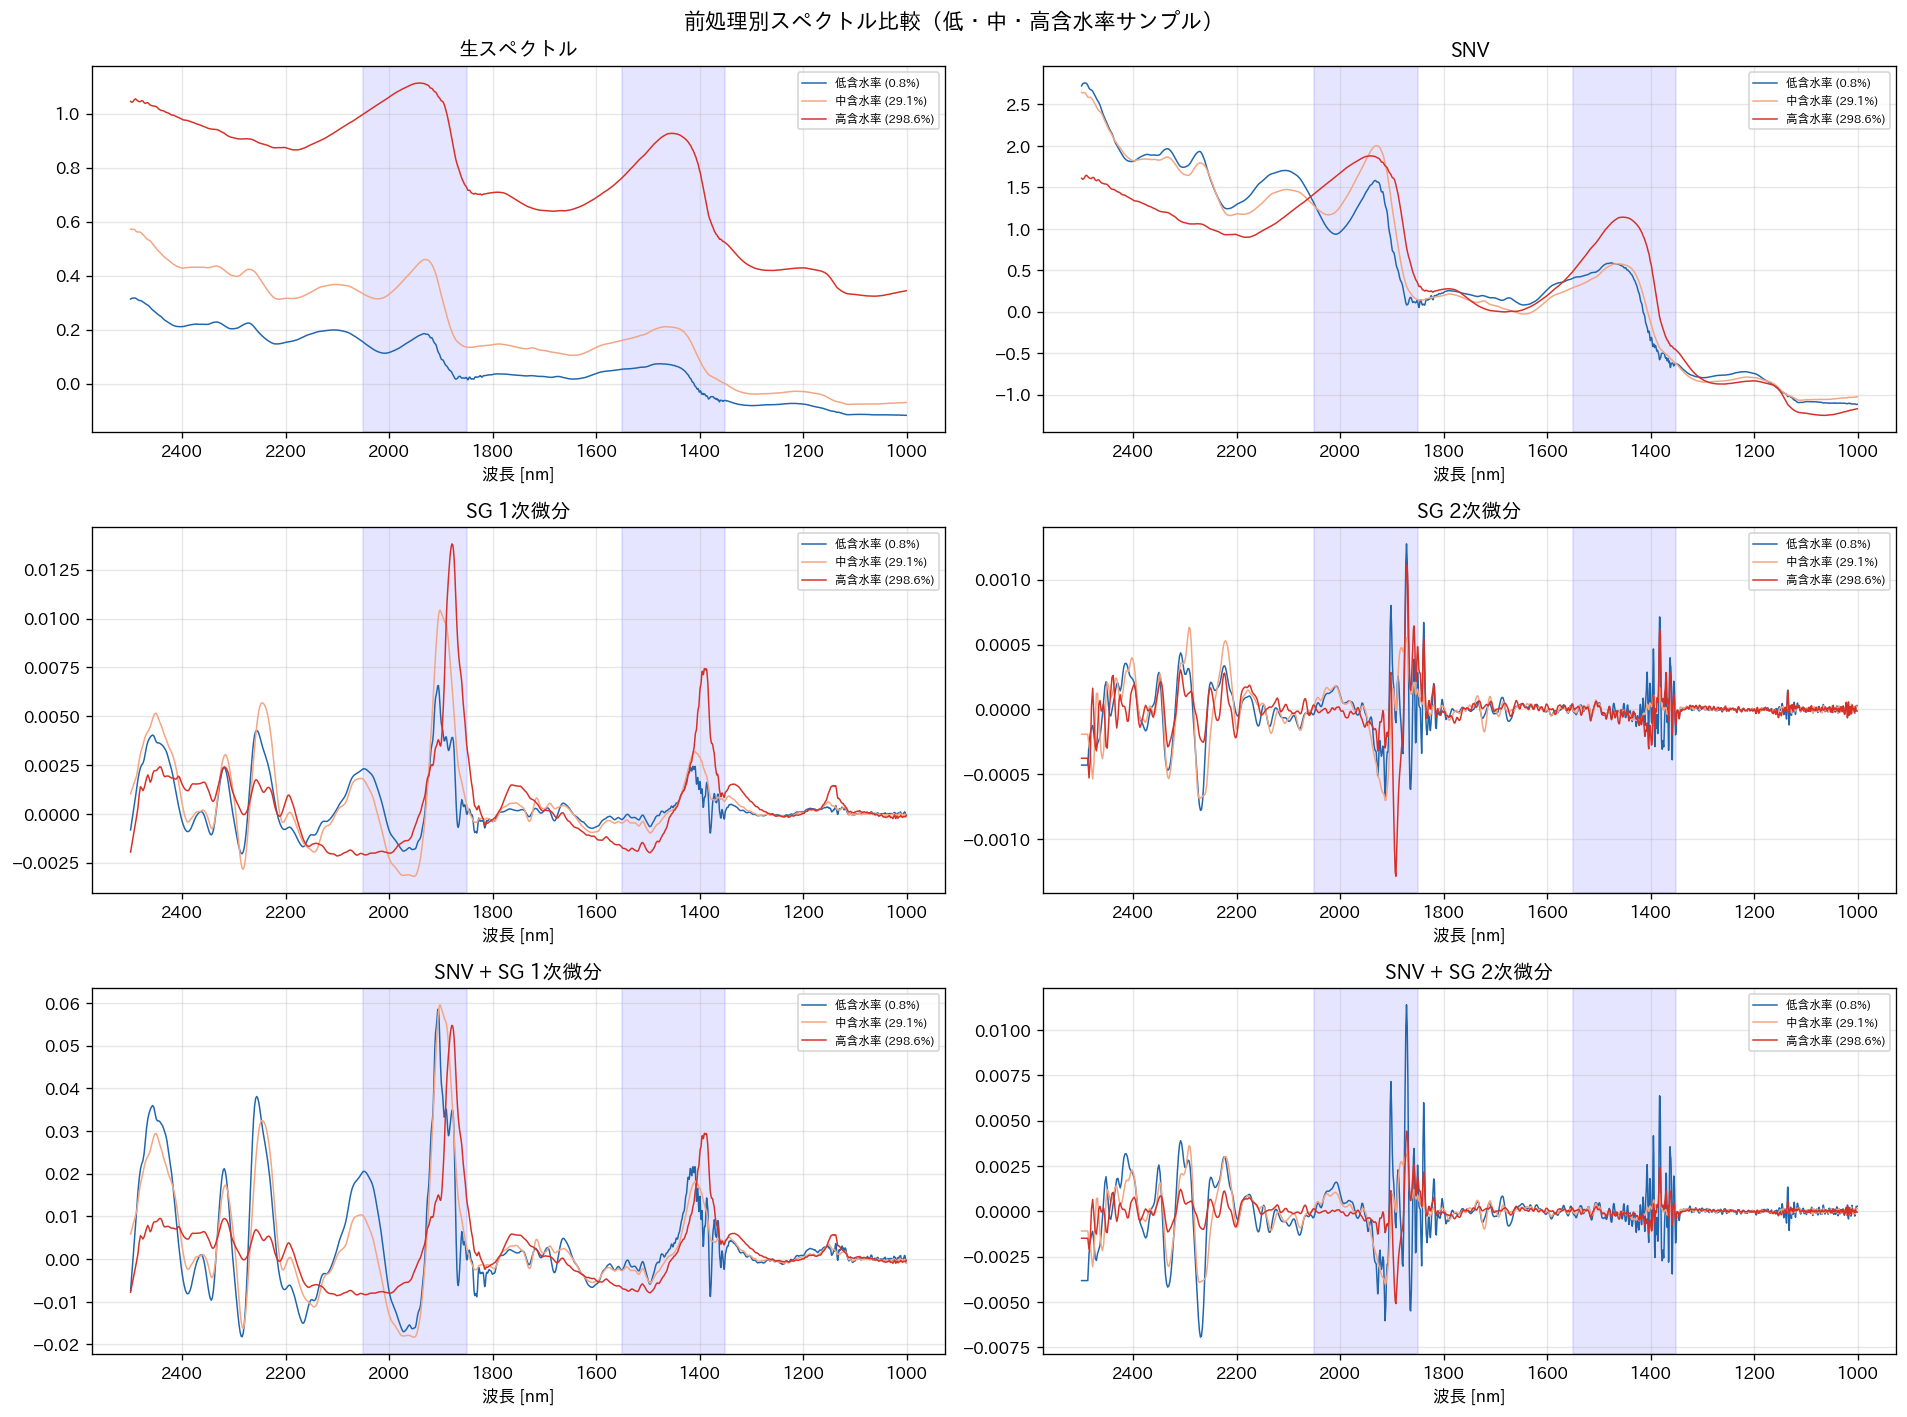

In [5]:
# 含水率の低・中・高からサンプルを1つずつ選ぶ
idx_low  = np.argmin(y_train)
idx_high = np.argmax(y_train)
idx_mid  = np.argmin(np.abs(y_train - np.median(y_train)))
sample_indices = [idx_low, idx_mid, idx_high]
sample_labels  = [
    f'低含水率 ({y_train[idx_low]:.1f}%)',
    f'中含水率 ({y_train[idx_mid]:.1f}%)',
    f'高含水率 ({y_train[idx_high]:.1f}%)',
]
colors = ['#2166ac', '#f4a582', '#d73027']

water_bands = [(1350, 1550), (1850, 2050)]

datasets = [
    ('生スペクトル',    X_train),
    ('SNV',            X_train_snv),
    ('SG 1次微分',     X_train_sg1),
    ('SG 2次微分',     X_train_sg2),
    ('SNV + SG 1次微分', X_train_snv_sg1),
    ('SNV + SG 2次微分', X_train_snv_sg2),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (title, X) in zip(axes, datasets):
    for idx, label, color in zip(sample_indices, sample_labels, colors):
        ax.plot(WAVELENGTHS, X[idx], color=color, linewidth=0.9, label=label)
    for wl_min, wl_max in water_bands:
        ax.axvspan(wl_min, wl_max, alpha=0.1, color='blue')
    ax.set_title(title)
    ax.set_xlabel('波長 [nm]')
    ax.invert_xaxis()
    ax.legend(fontsize=7)

plt.suptitle('前処理別スペクトル比較（低・中・高含水率サンプル）', fontsize=13)
plt.tight_layout()
plt.savefig('figs/02_preprocessing_comparison.png', bbox_inches='tight')
plt.show()

## 5. 前処理後の含水率との相関比較

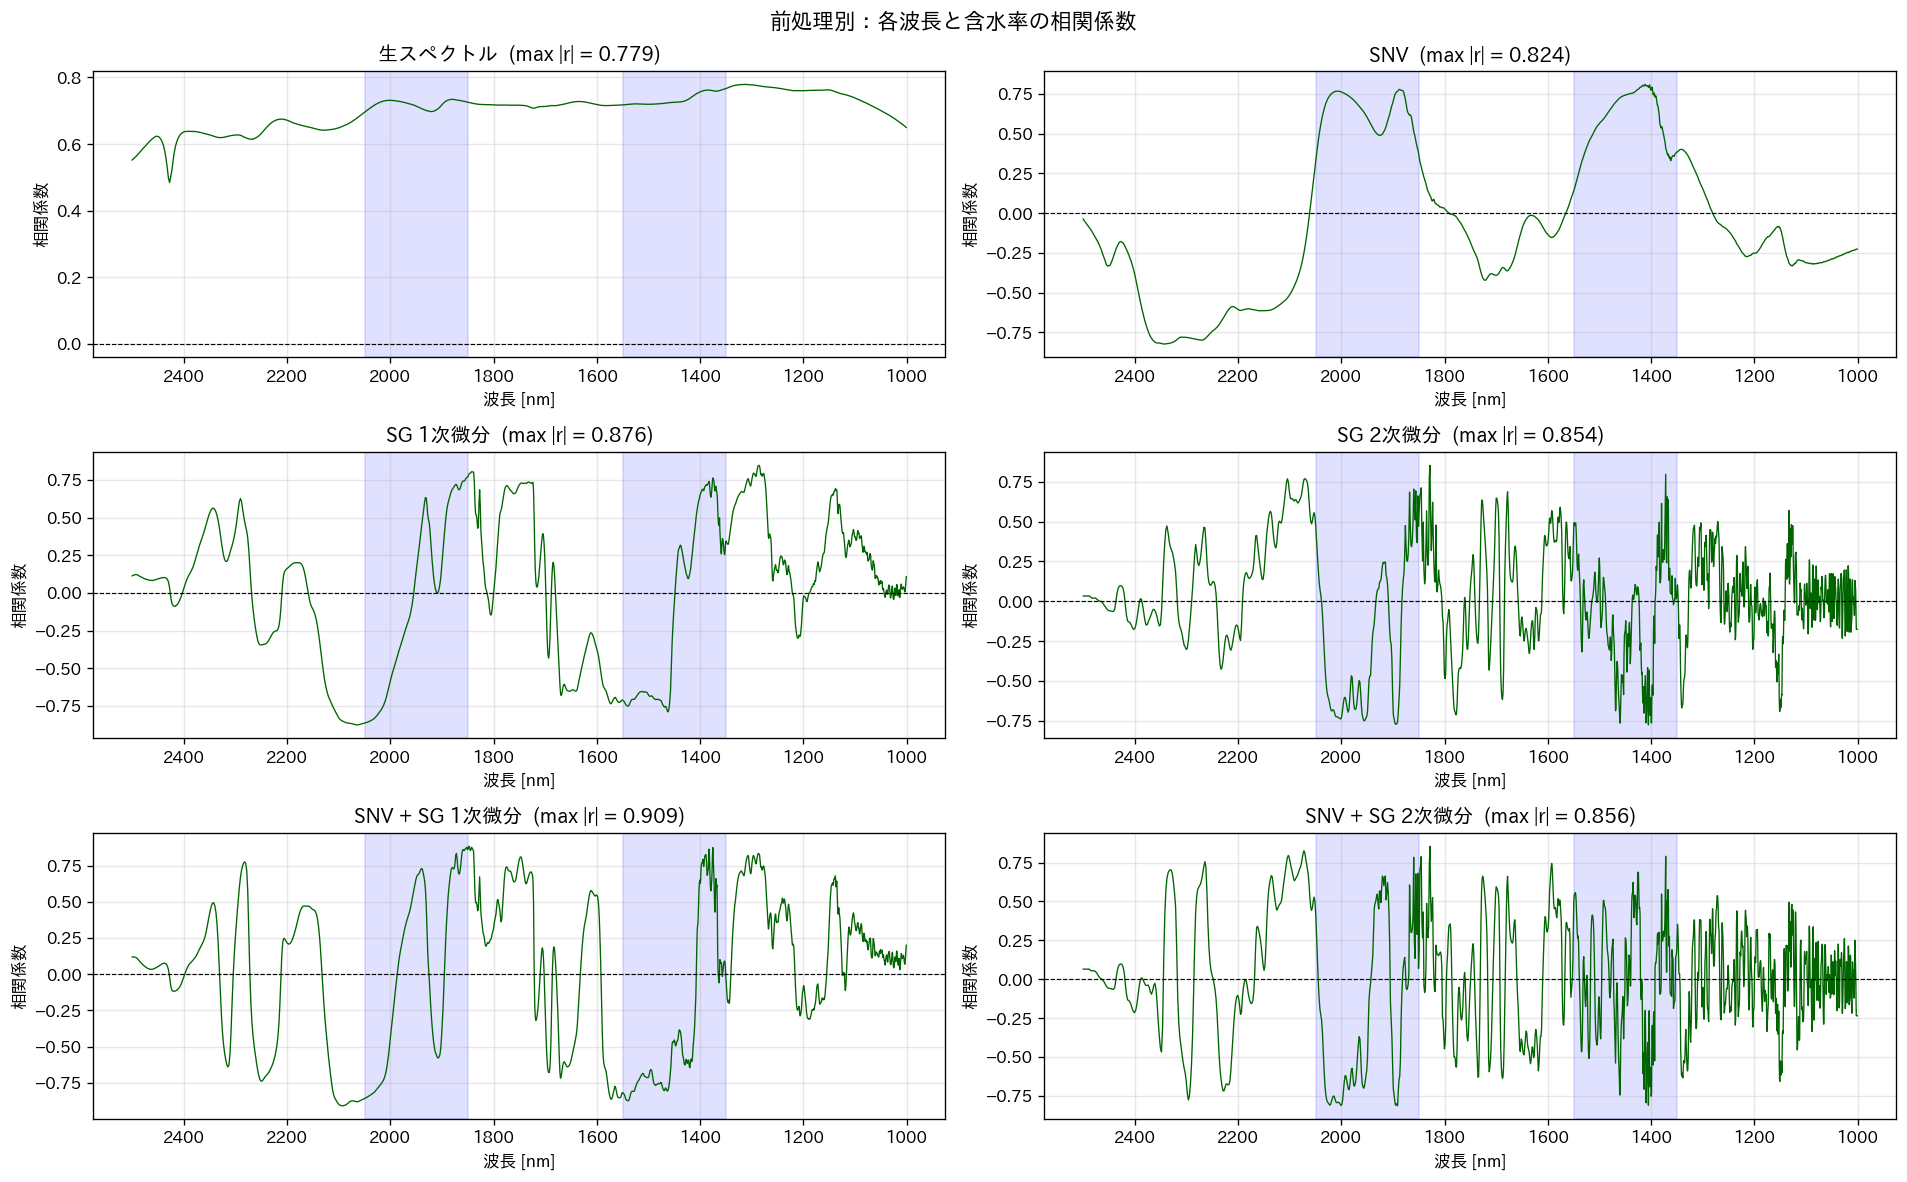

最大 |相関係数| の比較:
  生スペクトル                : 0.7791
  SNV                   : 0.8238
  SG 1次微分               : 0.8764
  SG 2次微分               : 0.8535
  SNV + SG 1次微分         : 0.9091
  SNV + SG 2次微分         : 0.8556


In [6]:
def calc_correlation(X, y):
    return np.array([np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])])

corr_raw     = calc_correlation(X_train, y_train)
corr_snv     = calc_correlation(X_train_snv, y_train)
corr_sg1     = calc_correlation(X_train_sg1, y_train)
corr_sg2     = calc_correlation(X_train_sg2, y_train)
corr_snv_sg1 = calc_correlation(X_train_snv_sg1, y_train)
corr_snv_sg2 = calc_correlation(X_train_snv_sg2, y_train)

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

corr_datasets = [
    ('生スペクトル',       corr_raw),
    ('SNV',               corr_snv),
    ('SG 1次微分',        corr_sg1),
    ('SG 2次微分',        corr_sg2),
    ('SNV + SG 1次微分',  corr_snv_sg1),
    ('SNV + SG 2次微分',  corr_snv_sg2),
]

for ax, (title, corr) in zip(axes, corr_datasets):
    ax.plot(WAVELENGTHS, corr, linewidth=0.8, color='darkgreen')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    for wl_min, wl_max in water_bands:
        ax.axvspan(wl_min, wl_max, alpha=0.12, color='blue')
    ax.set_title(f'{title}  (max |r| = {np.abs(corr).max():.3f})')
    ax.set_xlabel('波長 [nm]')
    ax.set_ylabel('相関係数')
    ax.invert_xaxis()

plt.suptitle('前処理別：各波長と含水率の相関係数', fontsize=13)
plt.tight_layout()
plt.savefig('figs/02_correlation_comparison.png', bbox_inches='tight')
plt.show()

print('最大 |相関係数| の比較:')
for title, corr in corr_datasets:
    print(f'  {title:<22}: {np.abs(corr).max():.4f}')

## 6. SG パラメータのチューニング
`window_length` と `polyorder` の組み合わせで相関がどう変わるか確認する。

In [7]:
window_lengths = [7, 11, 15, 21]
polyorders     = [2, 3]

results = []
for wl in window_lengths:
    for po in polyorders:
        if wl <= po:
            continue
        for deriv in [1, 2]:
            X_sg = sg_deriv(snv(X_train), window_length=wl, polyorder=po, deriv=deriv)
            corr = calc_correlation(X_sg, y_train)
            results.append({
                'window': wl,
                'poly': po,
                'deriv': deriv,
                'max_abs_corr': np.abs(corr).max(),
            })

df_results = pd.DataFrame(results).sort_values('max_abs_corr', ascending=False)
print(df_results.to_string(index=False))

 window  poly  deriv  max_abs_corr
      7     2      1      0.909870
     11     3      1      0.909843
     15     3      1      0.909428
     21     3      1      0.909419
     11     2      1      0.909099
      7     3      1      0.908094
     15     2      1      0.907864
     21     2      1      0.905746
     21     3      2      0.883713
     21     2      2      0.883713
     11     3      2      0.855567
     11     2      2      0.855567
     15     3      2      0.844186
     15     2      2      0.844186
      7     2      2      0.796096
      7     3      2      0.796096


## 7. 前処理済みデータの保存
次のノートブック（PLS回帰）で使用するため、各前処理の結果を保存する。

In [8]:
def save_processed(X_tr, X_te, name):
    df_tr = pd.DataFrame(X_tr, columns=SPEC_COLS)
    df_tr.insert(0, '含水率', y_train)
    df_te = pd.DataFrame(X_te, columns=SPEC_COLS)

    df_tr.to_csv(f'../data/processed/train_{name}.csv', index=False)
    df_te.to_csv(f'../data/processed/test_{name}.csv',  index=False)
    print(f'保存完了: train_{name}.csv / test_{name}.csv')

save_processed(X_train,          X_test,          'raw')
save_processed(X_train_snv,      X_test_snv,      'snv')
save_processed(X_train_sg1,      X_test_sg1,      'sg1')
save_processed(X_train_sg2,      X_test_sg2,      'sg2')
save_processed(X_train_snv_sg1,  X_test_snv_sg1,  'snv_sg1')
save_processed(X_train_snv_sg2,  X_test_snv_sg2,  'snv_sg2')

OSError: Cannot save file into a non-existent directory: '..\data\processed'

## 8. まとめ

| 前処理 | 特徴 | 用途 |
|--------|------|------|
| 生スペクトル | ベースライン | 比較基準 |
| SNV | 散乱補正、各スペクトルを標準化 | 樹種間のスケール差を吸収 |
| SG 1次微分 | ベースライン除去、傾き強調 | トレンド除去 |
| SG 2次微分 | ピーク分離、ベースライン完全除去 | 重なったピークの識別 |
| SNV + SG 1次微分 | 散乱補正 + ベースライン除去 | **最も汎用的な組み合わせ** |
| SNV + SG 2次微分 | 散乱補正 + ピーク分離 | 高周波ノイズが増えやすい |

### 次のステップ
- `03_baseline_pls.ipynb`: 各前処理でPLS回帰を実行してCVスコアを比較